<a href="https://colab.research.google.com/github/harshitha020505/DLLAB/blob/main/DLLab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

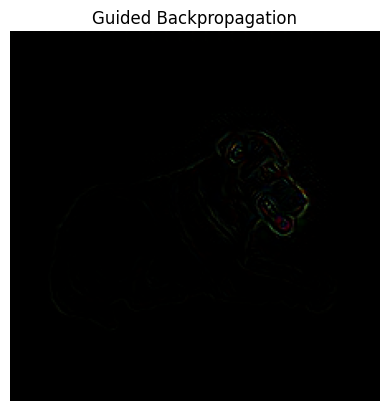

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

model = models.resnet18(pretrained=True)
model.eval()

def guided_relu_hook(module, grad_in, grad_out):
    return (torch.clamp(grad_in[0], min=0.0),)

for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.register_backward_hook(guided_relu_hook)

image = Image.open("sample2.jpeg").convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

input_img = transform(image).unsqueeze(0)
input_img.requires_grad = True

output = model(input_img)

target_class = output.argmax()

model.zero_grad()
output[0, target_class].backward()

gradients = input_img.grad.data.squeeze().permute(1, 2, 0).numpy()

plt.imshow(gradients)
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()